In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jeet

In [18]:
df = pd.read_csv("Verrucodesmus_verrucosus.csv")

In [19]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [20]:
jeet.SilhouetteScore(df)

K=2, Score=0.521135257107163
K=3, Score=0.5779503670490901
K=4, Score=0.5549367029337313
K=5, Score=0.5687392158998356
K=6, Score=0.5451386359411622
K=7, Score=0.510896239162659


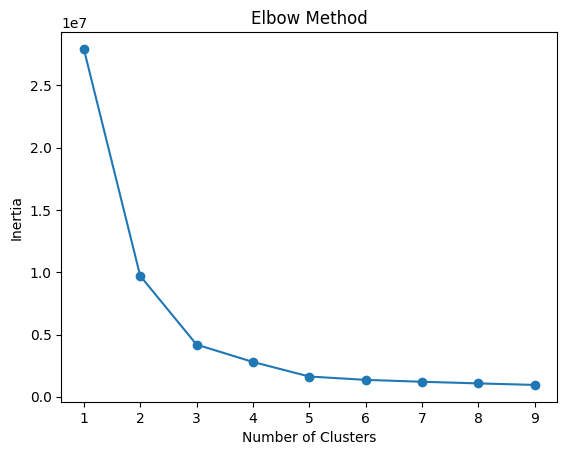

In [21]:
jeet.ElbowMethod(df)

In [22]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(x_scaled)

In [23]:
jeet.ClusterSummary(df)

         Irradiance         NO3  Temperature        pH   Biomass    O2 Gas  \
Cluster                                                                      
0        135.706804  150.795565    22.101232  6.969297  0.807264  9.498676   
1        146.051893   46.762622    22.580575  8.288869  2.370616  9.288741   

            CO2 Gas        OD  Conductivity  
Cluster                                      
0        773.553926  7.562964     267.14080  
1        535.406711  7.227642     290.60552  


In [43]:
cluster_summary = df.groupby('Cluster').count()
print(cluster_summary)

         Irradiance  NO3  Temperature   pH  Biomass  O2 Gas  CO2 Gas   OD  \
Cluster                                                                     
0               484  484          484  484      484     484      484  484   
1               596  596          596  596      596     596      596  596   

         Conductivity  PCA1  PCA2  
Cluster                            
0                 484   484   484  
1                 596   596   596  


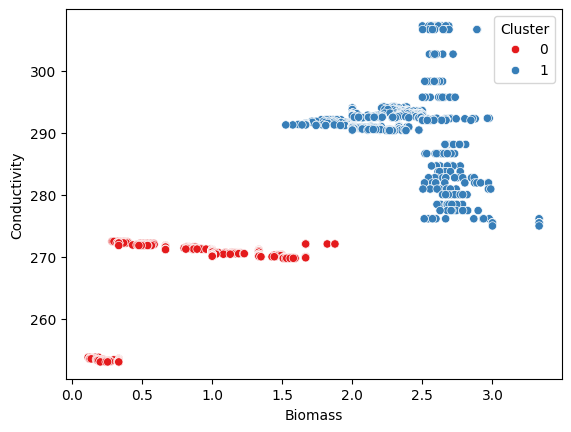

In [45]:
sns.scatterplot(data=df, x='Biomass', y='Conductivity', hue='Cluster', palette='Set1')
plt.show()

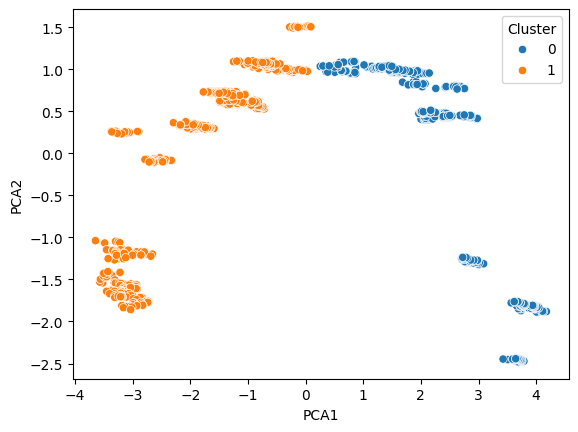

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster')
plt.show()

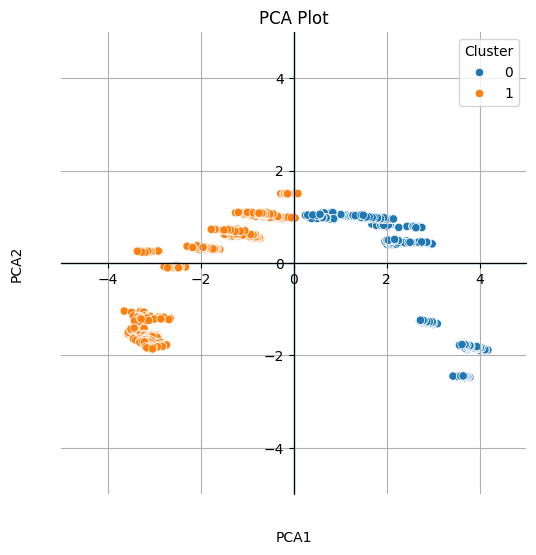

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster')

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-5, 5)
plt.ylim(-5, 5)

ax = plt.gca()

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.xaxis.set_label_coords(0.5, -0.08)
ax.yaxis.set_label_coords(-0.08, 0.5)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")

plt.title("PCA Plot")
plt.grid()
plt.show()